# Part 4: Exploratory Data Analysis of Weather Dataset

## 4.0) Imports and loading the training set
The training set is located in the `processed/` folder.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
df = pd.read_csv(r"C:\Users\yanis\OneDrive\Documents\GitHub\CST8504_Assignment1\data\processed\weather_data_train.csv")

## 4.1) Distribution of Target (`day_type`)
The target column, day_type, contains five weather categories: Sunny, Cloudy, Hot, Cold, and Rainy. Sunny has the most examples, while Rainy has the fewest. The categories have unequal numbers of examples.

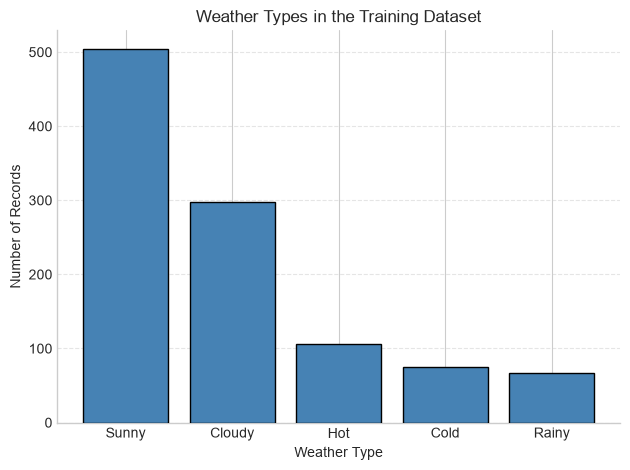

In [7]:
day_type_counts = df['day_type'].value_counts()

plt.bar(day_type_counts.index, day_type_counts.values, color='steelblue', edgecolor='black', zorder=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.title("Weather Types in the Training Dataset")
plt.xlabel("Weather Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

This box plot compares humidity across the five weather types. It shows the typical humidity and how much it varies within each category, helping us explore whether humidity could help distinguish weather types.

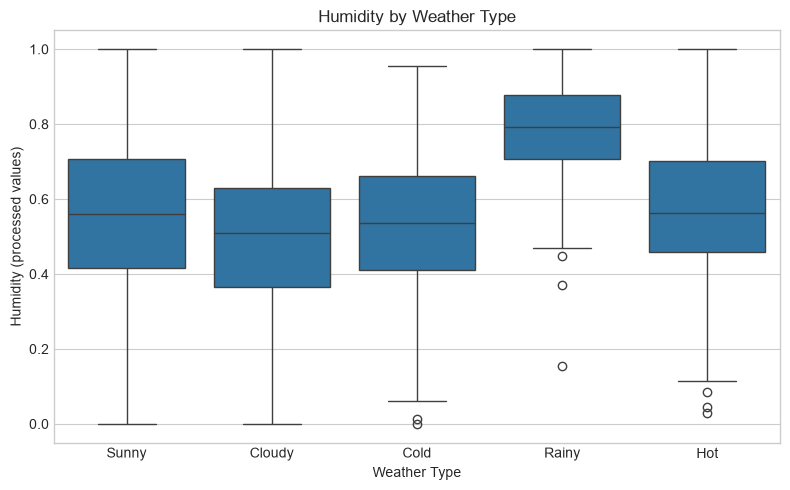

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day_type", y="humidity")

plt.title("Humidity by Weather Type")
plt.xlabel("Weather Type")
plt.ylabel("Humidity (processed values)")
plt.tight_layout()
plt.show()

Rainy days have the highest median humidity in the training data. The other weather types overlap considerably, suggesting that humidity may help identify rainy days but may be less useful on its own for distinguishing the other categories.

## 4.2) Correlation Heatmap
This heatmap shows the relationships between the numeric features. Temperature (day_temp) and UV index (uv_index) have a strong positive correlation of approximately 0.82. This means higher temperatures generally occur with higher UV values in the training data.

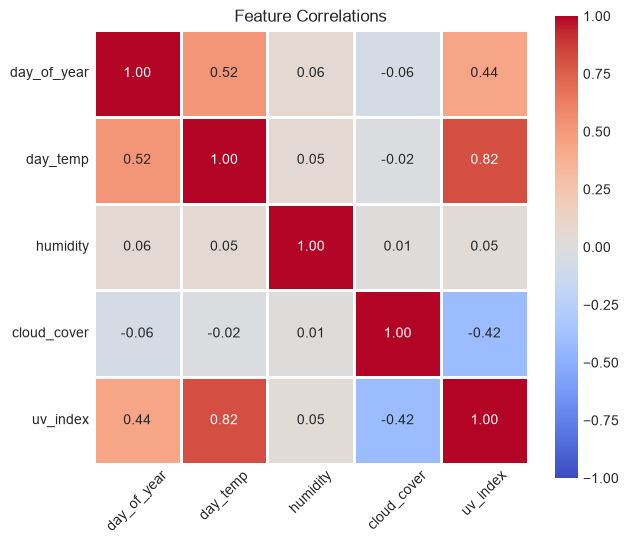

In [4]:
plt.figure(figsize=(7, 6))
df_map = df.corr(numeric_only=True)
sns.heatmap(df_map, linewidths=1, linecolor='white', annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title('Feature Correlations')
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.show()

# 4.3) Scatter Plot
Temperature and UV index generally increase together. Hot days tend to appear at higher values, while cold days tend to appear at lower values. The weather categories overlap, suggesting that these two features alone may not clearly distinguish every weather type.

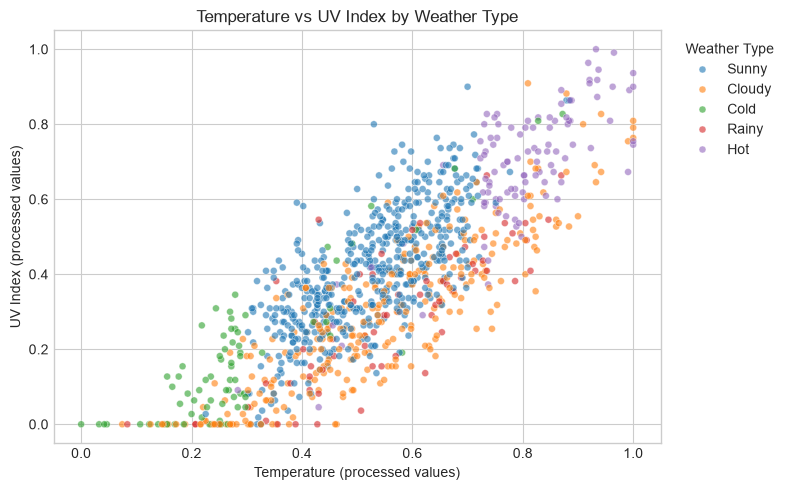

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="day_temp",
    y="uv_index",
    hue="day_type",
    alpha=0.6,
    s=25
)

plt.title("Temperature vs UV Index by Weather Type")
plt.xlabel("Temperature (processed values)")
plt.ylabel("UV Index (processed values)")
plt.legend(title="Weather Type", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 4.5) Trend over Time
This plot shows how temperature varies across the day-of-year values in the training data. Each grey dot represents one record. The blue line is a moving average of 30 records, which smooths the variation and makes the overall pattern easier to see.

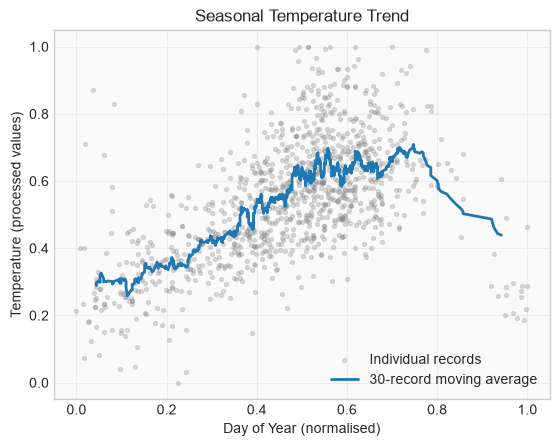

In [13]:
s = df.sort_values("day_of_year")
plt.scatter(s["day_of_year"], s["day_temp"],
            s=8, alpha=0.25, color="grey", label="Individual records")
plt.plot(s["day_of_year"],
         s["day_temp"].rolling(30, center=True).mean(),
         linewidth=2, label="30-record moving average")
plt.gca().set_facecolor('#fafafa')
plt.grid(alpha=0.3)
plt.xlabel('Day of Year (normalised)')
plt.ylabel('Temperature (processed values)')
plt.title('Seasonal Temperature Trend')
plt.legend()
plt.show()